# 回归

## 加州房价预测

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['PingFang SC', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

In [7]:
# ========== 1. 加载数据 ==========
print("=" * 60)
print("1. 加载加州房价数据集")
print("=" * 60)

housing = fetch_california_housing(as_frame=True)
X = housing.data
y = housing.target

print(f"样本数量: {X.shape[0]}")
print(f"特征数量: {X.shape[1]}")
print(f"特征名称: {list(X.columns)}")
print(f"目标变量: {housing.target_names[0]}（单位：十万美元）")
print(f"房价范围: ${y.min()*100000:.0f} - ${y.max()*100000:.0f}")

1. 加载加州房价数据集
样本数量: 20640
特征数量: 8
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
目标变量: MedHouseVal（单位：十万美元）
房价范围: $14999 - $500001


In [6]:
import pandas as pd

# 将数据保存为CSV文件，方便下次本地读取
data = housing.data.copy()
data['target'] = housing.target  # 将目标变量添加为列

# 保存到当前目录
data.to_csv('california_housing.csv', index=False)
print("数据已保存为 california_housing.csv")

数据已保存为 california_housing.csv


In [19]:
# ========== 2. 划分训练集和测试集 ==========
print("\n" + "=" * 60)
print("2. 划分训练集(80%)和测试集(20%)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# ========== 3. 特征标准化（岭回归需要） ==========
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


2. 划分训练集(80%)和测试集(20%)
训练集: 16512 样本
测试集: 4128 样本


In [20]:
# ========== 4. 训练线性回归模型 ==========
print("\n" + "=" * 60)
print("3. 训练线性回归模型")
print("=" * 60)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"均方误差(MSE): {mse_lr:.4f}")
print(f"R²分数: {r2_lr:.4f}")


3. 训练线性回归模型
均方误差(MSE): 0.5559
R²分数: 0.5758


In [21]:
# ========== 5. 训练岭回归模型（对比） ==========
print("\n" + "=" * 60)
print("4. 训练岭回归模型 (α=1.0)")
print("=" * 60)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"均方误差(MSE): {mse_ridge:.4f}")
print(f"R²分数: {r2_ridge:.4f}")


4. 训练岭回归模型 (α=1.0)
均方误差(MSE): 0.5559
R²分数: 0.5758


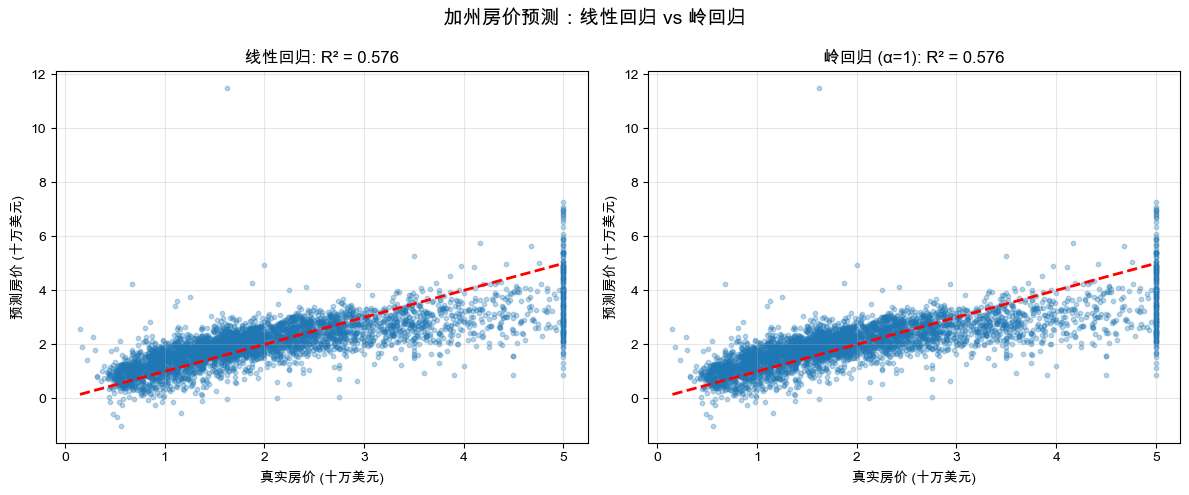

In [17]:
# ========== 6. 可视化：预测值 vs 真实值 ==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 线性回归
ax1 = axes[0]
ax1.scatter(y_test, y_pred_lr, alpha=0.3, s=10)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax1.set_xlabel('真实房价 (十万美元)')
ax1.set_ylabel('预测房价 (十万美元)')
ax1.set_title(f'线性回归: R² = {r2_lr:.3f}')
ax1.grid(alpha=0.3)

# 岭回归
ax2 = axes[1]
ax2.scatter(y_test, y_pred_ridge, alpha=0.3, s=10)
ax2.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax2.set_xlabel('真实房价 (十万美元)')
ax2.set_ylabel('预测房价 (十万美元)')
ax2.set_title(f'岭回归 (α=1): R² = {r2_ridge:.3f}')
ax2.grid(alpha=0.3)

plt.suptitle('加州房价预测：线性回归 vs 岭回归', fontsize=14)
plt.tight_layout()
plt.show()


5. 特征重要性（线性回归系数）
  MedInc: 0.8544
  AveBedrms: 0.3393
  HouseAge: 0.1225
  Population: -0.0023
  AveOccup: -0.0408
  AveRooms: -0.2944
  Longitude: -0.8698
  Latitude: -0.8969


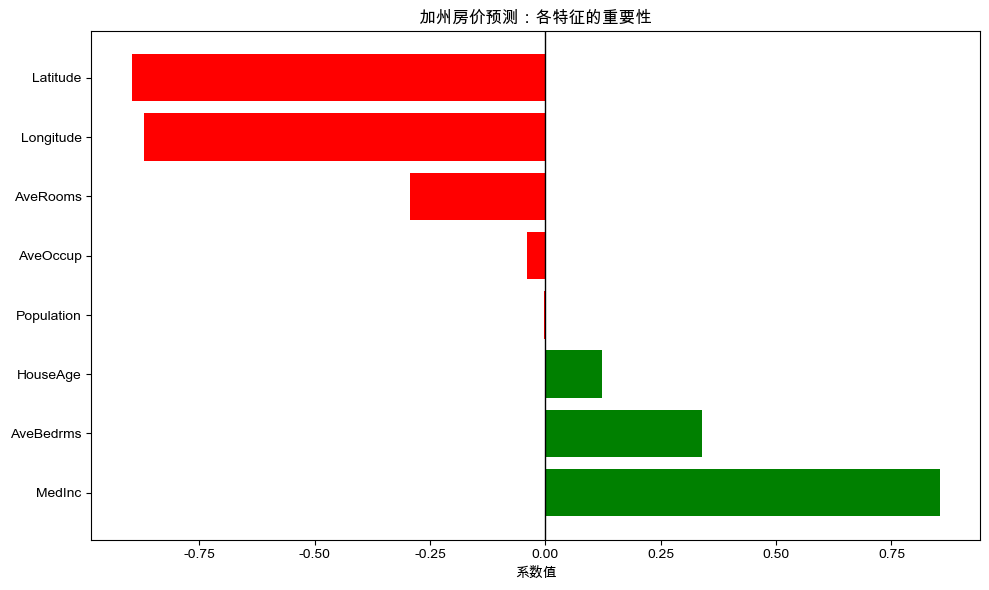

In [18]:
# ========== 7. 特征重要性分析 ==========
print("\n" + "=" * 60)
print("5. 特征重要性（线性回归系数）")
print("=" * 60)

coef_df = pd.DataFrame({
    '特征': X.columns,
    '系数': lr.coef_
}).sort_values('系数', ascending=False)

for _, row in coef_df.iterrows():
    print(f"  {row['特征']}: {row['系数']:.4f}")

# 可视化特征系数
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in coef_df['系数']]
ax.barh(coef_df['特征'], coef_df['系数'], color=colors)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('系数值')
ax.set_title('加州房价预测：各特征的重要性')
plt.tight_layout()
plt.show()